In [46]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
%matplotlib inline
import corner
import sys
import utils_nsbh as ut_new
import utils_old as ut_old


from scipy.stats import loguniform
from scipy.integrate import cumtrapz
import h5py
import copy
import numpy.lib.recfunctions as rfn
from tqdm import tqdm
import importlib


In [47]:
importlib.reload(ut_new)

<module 'utils_nsbh' from '/home/muhammed.saleem/projects/rprocess/bns-nsbh-rproc/explore/utils_nsbh.py'>

## Commandline

```
python3 CalculateEnrichmentHistory.py "$1" "$2" "$3" "$4" --alpha="-3.,-0.5" --tmin="1e-2,2.01" --xsfh="1e-3,0.999" --nmarg=500
```

In [48]:
EJECTAPATH = "../etc/mej_rate_lcehl_psr+gw+nicer.dat"
mej_dyn, mej_dsk, rate = np.loadtxt(EJECTAPATH, unpack=True)
mej = mej_dyn + mej_dsk
rate = rate*(1e9*1e-2)/1e6 # convert to Gpc^-3 yr^-1


In [39]:
rate.shape

(1500,)

In [40]:
pwd

'/home/muhammed.saleem/projects/rprocess/bns-nsbh-rproc/explore'

In [49]:
data = np.vstack([mej_dyn, mej_dsk, rate]).T
labels = [r"$M_{ej}^{dyn}$", r"$M_{ej}^{dsk}$", r"$\mathrm{Rate}$"]
#figure = corner.corner(data, labels=labels, show_titles=True, title_fmt=".2f")

In [50]:
DTDPATH = './../etc/Zevin22_sgrb_dtd.dat'
NUM = 100
ndtd = NUM # number of DTD samples to draw


In [51]:
alpha, tdmin, tdmax = np.loadtxt(DTDPATH, unpack=True, skiprows=1)
tdmin = tdmin/1e9 # convert to Gyr

idxs = np.random.choice(range(len(alpha)),ndtd,False)
alphas = alpha[idxs]
tdmins = tdmin[idxs]



In [52]:
tdmin

array([0.27301505, 0.26724683, 0.08882686, ..., 0.17741182, 0.1639827 ,
       0.16526642])

In [44]:
alpha.shape

(9184,)

In [8]:
idxs

array([5626, 1330, 3899, 7796, 4568, 3409,  220, 1142, 3056, 3542, 5334,
       6529, 5310, 1964, 2912, 1859, 1086, 3843, 9125, 5735, 2314, 4410,
       1390, 8966, 8308, 7722, 5761, 8588, 6678, 4203, 6617, 4407, 4055,
       1625, 3530,  343, 3219, 1879,  602, 5449, 2586, 8721, 7319, 9046,
       2491,  927, 5112, 1823, 8799,  183, 8488, 1704, 5122, 3656,  398,
       5692, 7347, 3718, 5609, 2311, 4970, 2828, 1409,  961, 2352, 4303,
       5089, 1766, 9031, 3648, 3017, 2986, 5946,  328, 8384, 8139, 4806,
       1425, 1549, 5805, 3282, 5528, 2998, 6806, 8354, 5872, 6385, 2424,
       2412, 2218, 6928,  642,  560, 8240, 1514, 5702, 4539, 4076, 4100,
       7310])

## xsfh OR EU_RATIO_Z0_BOUNDS

(1e-6,1.) 
bounds for log-uniform prior on fractional contribution of collapsar channel to local r-process mass x rate density (i.e. m_Eu_coll x norm_coll/(m_Eu_coll x norm_coll + m_Eu_bns x norm_bns))

fractional contribution given by 
$$ X_{coll} = m_{Eu,coll} \times N_{coll}/(m_{Eu,coll} \times N_{coll} + m_{Eu,bns} \times N_{bns}) $$


In [53]:
xsfh="1e-3,0.999"
EU_RATIO_Z0_BOUNDS = [float(bnd) for bnd in str(xsfh).split(',')] 
EU_RATIO_Z0_BOUNDS

[0.001, 0.999]

## Draw 100 samples for the fraction of collapsar yield

Eu_ratio_z0 = loguniform.rvs(*EU_RATIO_Z0_BOUNDS,size=ndtd) # log-uniform prior on ratio of collapsar to total Eu abundance at z=0 

In [54]:
# uniform prior on ratio of collapsar to total Eu abundance at z=0
Eu_ratio_z0s = np.random.uniform(*EU_RATIO_Z0_BOUNDS,ndtd) 

In [11]:
Eu_ratio_z0s.shape

(100,)

## samples for BNS rate and ejecta

number of rate, mej samples per r-process yield prediction


In [55]:
NUM_MARG = 200
nsamps = NUM_MARG
ej_idxs = np.random.choice(range(len(mej)),nsamps,False) # sample in ejecta mass and rate
mejs = mej[ej_idxs]
rates = rate[ej_idxs]


In [56]:
mejs

array([0.06688454, 0.04517493, 0.11050997, 0.0308349 , 0.03770663,
       0.02289432, 0.09385264, 0.0116232 , 0.07377085, 0.02096924,
       0.06171118, 0.08720154, 0.08496063, 0.01173133, 0.01664293,
       0.05755973, 0.08727734, 0.15791435, 0.07090516, 0.01566574,
       0.05714005, 0.05856786, 0.02576894, 0.00424945, 0.0497648 ,
       0.05038647, 0.10034438, 0.02767698, 0.06556575, 0.03023255,
       0.03789947, 0.12454331, 0.06684612, 0.01402547, 0.01676486,
       0.10002862, 0.02614975, 0.06676494, 0.04361209, 0.05410096,
       0.00731977, 0.03291714, 0.01798844, 0.05008842, 0.04390739,
       0.10186712, 0.02928858, 0.04942533, 0.0906394 , 0.08151764,
       0.0115308 , 0.04869129, 0.0511594 , 0.03124127, 0.04705166,
       0.03961885, 0.03721012, 0.06449367, 0.05963004, 0.01375176,
       0.05758163, 0.04522338, 0.0365286 , 0.03438625, 0.03829939,
       0.02145601, 0.01906438, 0.08121877, 0.07433174, 0.09062053,
       0.03202035, 0.02678204, 0.17341781, 0.0466986 , 0.03366

## do r-process yield calculation, using Daniel Siegel's one-zone model


In [57]:
for i,(alpha,tdmin,Xcoll) in enumerate(zip(alphas,tdmins,Eu_ratio_z0s)):
    print (i,alpha,tdmin,Xcoll)
    if i > 0:
        break


0 -2.059498289145709 0.2234352007022898 0.10788541017935559
1 -1.8811455163251398 0.19784231669709004 0.6196063611329244


In [58]:
for j,(mej,rate) in enumerate(zip(mejs,rates)):
    print(j, mej, rate)
    if j > 0:
        break

0 0.06688453630478262 83.72873646303248
1 0.045174929214125484 152.420089370895


## Run the loop for  i = 1, j = 1

In [53]:
print (i,alpha,tdmin,Xcoll)

1 -2.1687593377910943 0.18592536350378147 0.26797195848277683


In [54]:
print(j, mej, rate)

1 0.04009639462244512 77.59659700857972


In [55]:
alpha

-2.1687593377910943

In [60]:
idx = nsamps*i+j


In [61]:
i, j, nsamps, idx

(1, 1, 200, 201)

## Run old rproc_evolution() where there is no NSBH channel

In [62]:
outdat = {}
outdat['pop'] = {}
outdat['yield'] = {}
outdat['frac'] = {}

Fe_H, r_Fe, rate_evolutions = ut_old.rproc_evolution(rate,mej,-alpha,tdmin,Xcoll,f_NSgal=0.5,nppdt=20)

Rbns, Rcoll, Xs, zs, ts = rate_evolutions

outdat['pop'][idx] = np.array([mej,rate,alpha,tdmin,Xcoll])
outdat['yield'][idx] = {}
outdat['yield'][idx]['Fe_H'] = Fe_H
outdat['yield'][idx]['Eu_Fe'] = r_Fe
outdat['frac'][idx] = {}
outdat['frac'][idx]['Rbns'] = Rbns
outdat['frac'][idx]['Rcoll'] = Rcoll
outdat['frac'][idx]['Xs'] = Xs
outdat['frac'][idx]['z'] = zs
outdat['frac'][idx]['t'] = ts

Rcoll0 = Rcoll[-1]
mcoll = mej*rate/((1./Xcoll - 1.)*Rcoll0)
num = cumtrapz(mej*Rbns,ts)
denom = cumtrapz(mcoll*Rcoll,ts)
Xts = 1./(1.+num/denom)

outdat['frac'][idx]['X'] = list(Xts)+[Xts[-1]]

outdat_old = copy.deepcopy(outdat)

/tmp/ipykernel_581375/1183683459.py:23: DeprecationWarning: 'scipy.integrate.cumtrapz' is deprecated in favour of 'scipy.integrate.cumulative_trapezoid' and will be removed in SciPy 1.14.0
  num = cumtrapz(mej*Rbns,ts)
/tmp/ipykernel_581375/1183683459.py:24: DeprecationWarning: 'scipy.integrate.cumtrapz' is deprecated in favour of 'scipy.integrate.cumulative_trapezoid' and will be removed in SciPy 1.14.0
  denom = cumtrapz(mcoll*Rcoll,ts)


## Test 1 on NSBH channel: 
## Switch off NSBH channel and get the same output as before from BNS+Coll analysis

In [169]:
# use nsbh parameter as borrowed from bns parameters 
rate_nsbh  = copy.deepcopy(rate)
mej_nsbh   = copy.deepcopy(mej)
alpha_nsbh = copy.deepcopy(alpha)
tdmin_nsbh = copy.deepcopy(tdmin)


In [170]:
outdat = {}
outdat['pop'] = {}
outdat['yield'] = {}
outdat['frac'] = {}


Fe_H, r_Fe, rate_evolutions = ut_new.rproc_evolution_nsbh(
                                    rate,
                                    rate_nsbh,
                                    mej,
                                    mej_nsbh,
                                    -alpha,
                                    -alpha_nsbh,
                                    tdmin,
                                    tdmin_nsbh,
                                    Xcoll,
                                    f_NSgal=0.5,nppdt=20,
                                    add_NSBH = False)

Rbns, Rnsbh, Rcoll, Xs, zs, ts = rate_evolutions

outdat['pop'][idx] = np.array([mej,rate,alpha,tdmin,mej_nsbh,rate_nsbh,alpha_nsbh,tdmin_nsbh,Xcoll])
outdat['yield'][idx] = {}
outdat['yield'][idx]['Fe_H'] = Fe_H
outdat['yield'][idx]['Eu_Fe'] = r_Fe
outdat['frac'][idx] = {}
outdat['frac'][idx]['Rbns'] = Rbns
outdat['frac'][idx]['Rnsbh'] = Rnsbh
outdat['frac'][idx]['Rcoll'] = Rcoll
outdat['frac'][idx]['Xs'] = Xs
outdat['frac'][idx]['z'] = zs
outdat['frac'][idx]['t'] = ts

Rcoll0 = Rcoll[-1]
mcoll = (mej*rate+mej_nsbh*rate_nsbh)/((1./Xcoll - 1.)*Rcoll0)
num = cumtrapz(mej*Rbns+mej_nsbh*Rnsbh,ts)
denom = cumtrapz(mcoll*Rcoll,ts)
Xts = 1./(1.+num/denom)

outdat['frac'][idx]['X'] = list(Xts)+[Xts[-1]]

outdat_nsbh_off = copy.deepcopy(outdat)

/tmp/ipykernel_1185404/977235192.py:36: DeprecationWarning: 'scipy.integrate.cumtrapz' is deprecated in favour of 'scipy.integrate.cumulative_trapezoid' and will be removed in SciPy 1.14.0
  num = cumtrapz(mej*Rbns+mej_nsbh*Rnsbh,ts)
/tmp/ipykernel_1185404/977235192.py:37: DeprecationWarning: 'scipy.integrate.cumtrapz' is deprecated in favour of 'scipy.integrate.cumulative_trapezoid' and will be removed in SciPy 1.14.0
  denom = cumtrapz(mcoll*Rcoll,ts)


## Test 2 on NSBH channel: 
## Set BNS local rate to zero, and then use NSBH channel to do the BNS+Coll analysis

In [171]:
outdat = {}
outdat['pop'] = {}
outdat['yield'] = {}
outdat['frac'] = {}

zero_bns_rate = 0.0

Fe_H, r_Fe, rate_evolutions = ut_new.rproc_evolution_nsbh(
                                    zero_bns_rate,
                                    rate_nsbh,
                                    mej,
                                    mej_nsbh,
                                    -alpha,
                                    -alpha_nsbh,
                                    tdmin,
                                    tdmin_nsbh,
                                    Xcoll,
                                    f_NSgal=0.5,nppdt=20,
                                    add_NSBH = True)

Rbns, Rnsbh, Rcoll, Xs, zs, ts = rate_evolutions

outdat['pop'][idx] = np.array([mej,rate,alpha,tdmin,mej_nsbh,rate_nsbh,alpha_nsbh,tdmin_nsbh,Xcoll])
outdat['yield'][idx] = {}
outdat['yield'][idx]['Fe_H'] = Fe_H
outdat['yield'][idx]['Eu_Fe'] = r_Fe
outdat['frac'][idx] = {}
outdat['frac'][idx]['Rbns'] = Rbns
outdat['frac'][idx]['Rnsbh'] = Rnsbh
outdat['frac'][idx]['Rcoll'] = Rcoll
outdat['frac'][idx]['Xs'] = Xs
outdat['frac'][idx]['z'] = zs
outdat['frac'][idx]['t'] = ts

Rcoll0 = Rcoll[-1]
mcoll = (mej*rate+mej_nsbh*rate_nsbh)/((1./Xcoll - 1.)*Rcoll0)
num1 = cumtrapz(mej*Rbns,ts)
num2 = cumtrapz(mej_nsbh*Rnsbh,ts)
num = num1 + num2
denom = cumtrapz(mcoll*Rcoll,ts)
Xts = 1./(1.+num/denom)

outdat['frac'][idx]['X'] = list(Xts)+[Xts[-1]]

outdat_bns_rate_zero = copy.deepcopy(outdat)

/tmp/ipykernel_1185404/2805141072.py:37: DeprecationWarning: 'scipy.integrate.cumtrapz' is deprecated in favour of 'scipy.integrate.cumulative_trapezoid' and will be removed in SciPy 1.14.0
  num1 = cumtrapz(mej*Rbns,ts)
/tmp/ipykernel_1185404/2805141072.py:38: DeprecationWarning: 'scipy.integrate.cumtrapz' is deprecated in favour of 'scipy.integrate.cumulative_trapezoid' and will be removed in SciPy 1.14.0
  num2 = cumtrapz(mej_nsbh*Rnsbh,ts)
/tmp/ipykernel_1185404/2805141072.py:40: DeprecationWarning: 'scipy.integrate.cumtrapz' is deprecated in favour of 'scipy.integrate.cumulative_trapezoid' and will be removed in SciPy 1.14.0
  denom = cumtrapz(mcoll*Rcoll,ts)


In [172]:
np.array(outdat_bns_rate_zero['frac'][201]['X'])

array([1.        , 1.        , 1.        , ..., 0.46518133, 0.46517314,
       0.46517314])

In [173]:
Xs

array([1.        , 1.        , 1.        , ..., 0.26797725, 0.26453215,
       0.26797196])

## Test 3 on NSBH channel: 
## Set BNS ejecta mass to zero, and then use NSBH channel to do the BNS+Coll analysis

In [174]:
outdat = {}
outdat['pop'] = {}
outdat['yield'] = {}
outdat['frac'] = {}

zero_bns_mej = 0.0

Fe_H, r_Fe, rate_evolutions = ut_new.rproc_evolution_nsbh(
                                    rate,
                                    rate_nsbh,
                                    zero_bns_mej,
                                    mej_nsbh,
                                    -alpha,
                                    -alpha_nsbh,
                                    tdmin,
                                    tdmin_nsbh,
                                    Xcoll,
                                    f_NSgal=0.5,nppdt=20,
                                    add_NSBH = True)

Rbns, Rnsbh, Rcoll, Xs, zs, ts = rate_evolutions

outdat['pop'][idx] = np.array([mej,rate,alpha,tdmin,mej_nsbh,rate_nsbh,alpha_nsbh,tdmin_nsbh,Xcoll])
outdat['yield'][idx] = {}
outdat['yield'][idx]['Fe_H'] = Fe_H
outdat['yield'][idx]['Eu_Fe'] = r_Fe
outdat['frac'][idx] = {}
outdat['frac'][idx]['Rbns'] = Rbns
outdat['frac'][idx]['Rnsbh'] = Rnsbh
outdat['frac'][idx]['Rcoll'] = Rcoll
outdat['frac'][idx]['Xs'] = Xs
outdat['frac'][idx]['z'] = zs
outdat['frac'][idx]['t'] = ts

Rcoll0 = Rcoll[-1]
mcoll = (mej*rate+mej_nsbh*rate_nsbh)/((1./Xcoll - 1.)*Rcoll0)
num = cumtrapz(mej*Rbns+mej_nsbh*Rnsbh,ts)
denom = cumtrapz(mcoll*Rcoll,ts)
Xts = 1./(1.+num/denom)

outdat['frac'][idx]['X'] = list(Xts)+[Xts[-1]]

outdat_bns_mej_zero = copy.deepcopy(outdat)

/tmp/ipykernel_1185404/916788618.py:37: DeprecationWarning: 'scipy.integrate.cumtrapz' is deprecated in favour of 'scipy.integrate.cumulative_trapezoid' and will be removed in SciPy 1.14.0
  num = cumtrapz(mej*Rbns+mej_nsbh*Rnsbh,ts)
/tmp/ipykernel_1185404/916788618.py:38: DeprecationWarning: 'scipy.integrate.cumtrapz' is deprecated in favour of 'scipy.integrate.cumulative_trapezoid' and will be removed in SciPy 1.14.0
  denom = cumtrapz(mcoll*Rcoll,ts)


## Test 4 on NSBH channel: 
## Set BNS and NSBH ejecta mass to half the original, and then use BNS and NSBH channels together to do the original BNS+Coll analysis

In [175]:
outdat = {}
outdat['pop'] = {}
outdat['yield'] = {}
outdat['frac'] = {}

half_mej = 0.5 * mej 

Fe_H, r_Fe, rate_evolutions = ut_new.rproc_evolution_nsbh(
                                    rate,
                                    rate_nsbh,
                                    half_mej,
                                    half_mej,
                                    -alpha,
                                    -alpha_nsbh,
                                    tdmin,
                                    tdmin_nsbh,
                                    Xcoll,
                                    f_NSgal=0.5,nppdt=20,
                                    add_NSBH = True)

Rbns, Rnsbh, Rcoll, Xs, zs, ts = rate_evolutions

outdat['pop'][idx] = np.array([mej,rate,alpha,tdmin,mej_nsbh,rate_nsbh,alpha_nsbh,tdmin_nsbh,Xcoll])
outdat['yield'][idx] = {}
outdat['yield'][idx]['Fe_H'] = Fe_H
outdat['yield'][idx]['Eu_Fe'] = r_Fe
outdat['frac'][idx] = {}
outdat['frac'][idx]['Rbns'] = Rbns
outdat['frac'][idx]['Rnsbh'] = Rnsbh
outdat['frac'][idx]['Rcoll'] = Rcoll
outdat['frac'][idx]['Xs'] = Xs
outdat['frac'][idx]['z'] = zs
outdat['frac'][idx]['t'] = ts

Rcoll0 = Rcoll[-1]
mcoll = (mej*rate+mej_nsbh*rate_nsbh)/((1./Xcoll - 1.)*Rcoll0)
num = cumtrapz(mej*Rbns+mej_nsbh*Rnsbh,ts)
denom = cumtrapz(mcoll*Rcoll,ts)
Xts = 1./(1.+num/denom)

outdat['frac'][idx]['X'] = list(Xts)+[Xts[-1]]

outdat_mej_half = copy.deepcopy(outdat)

/tmp/ipykernel_1185404/2085544226.py:37: DeprecationWarning: 'scipy.integrate.cumtrapz' is deprecated in favour of 'scipy.integrate.cumulative_trapezoid' and will be removed in SciPy 1.14.0
  num = cumtrapz(mej*Rbns+mej_nsbh*Rnsbh,ts)
/tmp/ipykernel_1185404/2085544226.py:38: DeprecationWarning: 'scipy.integrate.cumtrapz' is deprecated in favour of 'scipy.integrate.cumulative_trapezoid' and will be removed in SciPy 1.14.0
  denom = cumtrapz(mcoll*Rcoll,ts)


In [176]:
np.array(outdat['frac'][idx]['X']) - Xs

array([0.        , 0.        , 0.        , ..., 0.03510829, 0.03854642,
       0.03510662])

## Comparing the outputs from all the above analyses
0. outdat_old
1. outdat_nsbh_off
2. outdat_bns_rate_zero
3. outdat_bns_mej_zero
4. outdat_mej_half

In [177]:
outdat_old['pop'][201], outdat_nsbh_off['pop'][201], outdat_bns_rate_zero['pop'][201], outdat_bns_mej_zero['pop'][201]


(array([ 4.00963946e-02,  7.75965970e+01, -2.16875934e+00,  1.85925364e-01,
         2.67971958e-01]),
 array([ 4.00963946e-02,  7.75965970e+01, -2.16875934e+00,  1.85925364e-01,
         4.00963946e-02,  7.75965970e+01, -2.16875934e+00,  1.85925364e-01,
         2.67971958e-01]),
 array([ 4.00963946e-02,  7.75965970e+01, -2.16875934e+00,  1.85925364e-01,
         4.00963946e-02,  7.75965970e+01, -2.16875934e+00,  1.85925364e-01,
         2.67971958e-01]),
 array([ 4.00963946e-02,  7.75965970e+01, -2.16875934e+00,  1.85925364e-01,
         4.00963946e-02,  7.75965970e+01, -2.16875934e+00,  1.85925364e-01,
         2.67971958e-01]))

Text(0, 0.5, 'Eu_Fe')

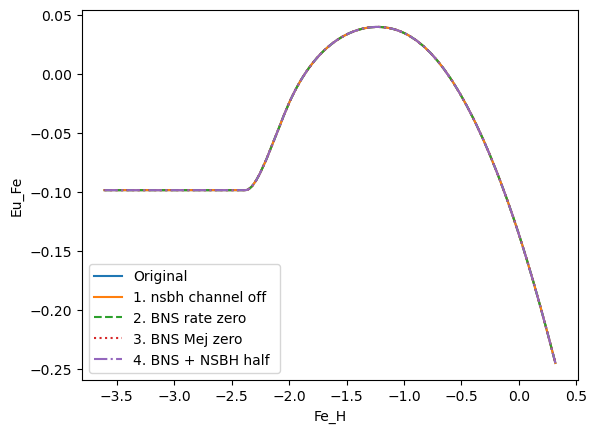

In [178]:
plt.plot(outdat_old['yield'][201]['Fe_H'],           outdat_old['yield'][201]['Eu_Fe'],          label = "Original")
plt.plot(outdat_nsbh_off['yield'][201]['Fe_H'],      outdat_nsbh_off['yield'][201]['Eu_Fe'],     label= "1. nsbh channel off")
plt.plot(outdat_bns_rate_zero['yield'][201]['Fe_H'], outdat_bns_rate_zero['yield'][201]['Eu_Fe'],label= "2. BNS rate zero", ls = 'dashed')
plt.plot(outdat_bns_mej_zero['yield'][201]['Fe_H'],  outdat_bns_mej_zero['yield'][201]['Eu_Fe'], label= "3. BNS Mej zero", ls = 'dotted')
plt.plot(outdat_mej_half['yield'][201]['Fe_H'],      outdat_mej_half['yield'][201]['Eu_Fe'],     label= "4. BNS + NSBH half ", ls = 'dashdot')

plt.legend()
plt.xlabel("Fe_H")
plt.ylabel("Eu_Fe")

In [179]:
outdat_old.keys()

dict_keys(['pop', 'yield', 'frac'])

In [180]:
outdat_old['yield'][201]

{'Fe_H': array([-3.60654425, -3.30989318, -3.13796228, ...,  0.31613237,
         0.31659417,  0.31705538]),
 'Eu_Fe': array([-0.09844033, -0.09844033, -0.09844033, ..., -0.24453327,
        -0.24470675, -0.24488245])}

In [181]:
outdat_old['frac'][201].keys()

dict_keys(['Rbns', 'Rcoll', 'Xs', 'z', 't', 'X'])

In [182]:
def make_sanity_plot_many_dicts(dict_name_list, x_key, x_subkey, y_key, y_subkey, legend_list):
    for dic in dict_name_list:
        if  y_key == 'yield':
            plt.plot(dic[x_key][201][x_subkey][:-1], dic[y_key][201][y_subkey])
        else:
            plt.plot(dic[x_key][201][x_subkey], dic[y_key][201][y_subkey])
    plt.xlabel(x_subkey)
    plt.ylabel(y_subkey)
    plt.legend(legend_list)

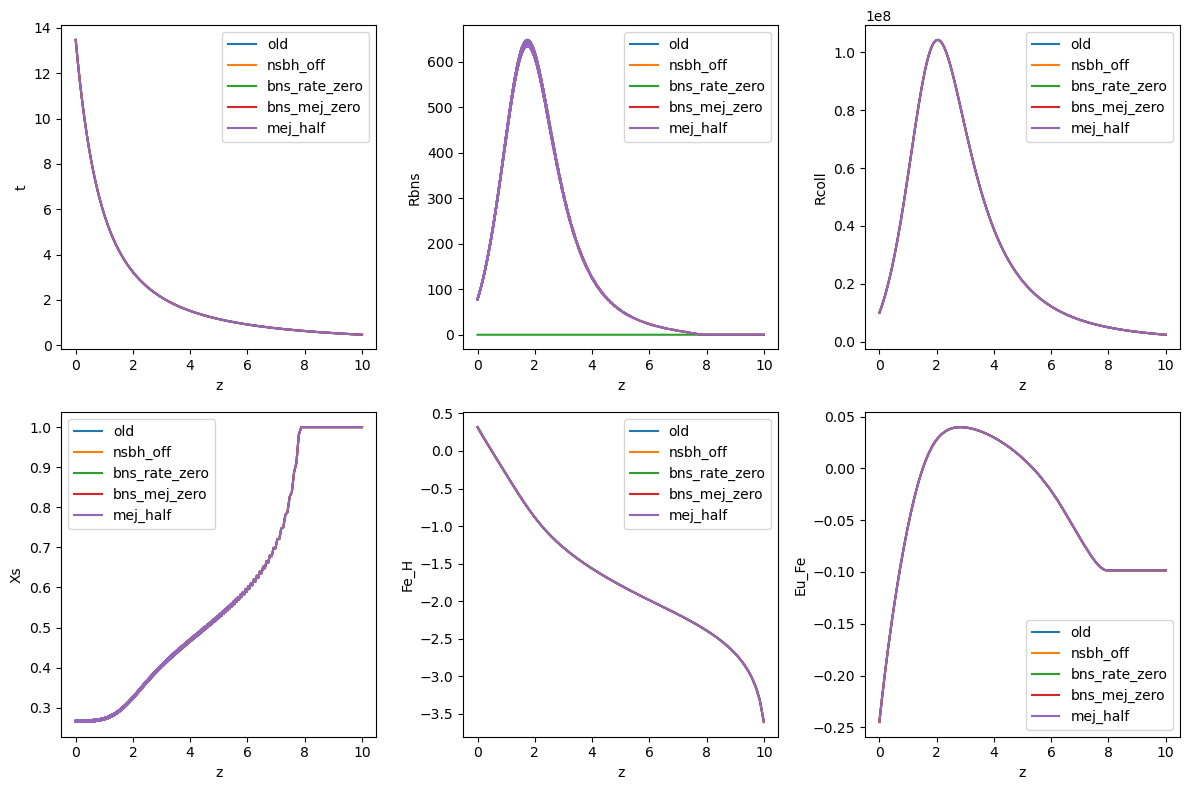

In [183]:
    

dict_name_list = [outdat_old, outdat_nsbh_off, outdat_bns_rate_zero, outdat_bns_mej_zero,outdat_mej_half]
legend_list = ['old', 'nsbh_off', 'bns_rate_zero', 'bns_mej_zero','mej_half']

plt.figure(figsize=(12,8))
plt.subplot(2,3, 1)
make_sanity_plot_many_dicts(dict_name_list, 'frac', 'z', 'frac', 't', legend_list)

plt.subplot(2,3, 2)
make_sanity_plot_many_dicts(dict_name_list, 'frac', 'z', 'frac', 'Rbns', legend_list)

plt.subplot(2,3, 3)
make_sanity_plot_many_dicts(dict_name_list, 'frac', 'z', 'frac', 'Rcoll', legend_list)

plt.subplot(2,3, 4)
make_sanity_plot_many_dicts(dict_name_list, 'frac', 'z', 'frac', 'Xs', legend_list)

plt.subplot(2,3, 5)
make_sanity_plot_many_dicts(dict_name_list, 'frac', 'z', 'yield', 'Fe_H', legend_list)

plt.subplot(2,3, 6)
make_sanity_plot_many_dicts(dict_name_list, 'frac', 'z', 'yield', 'Eu_Fe', legend_list)

plt.tight_layout()

## debug test by printing the outcomes of chemical evolution

In [192]:
importlib.reload(ut_new)


<module 'utils_nsbh' from '/home/muhammed.saleem/projects/rprocess/bns-nsbh-rproc/explore/utils_nsbh.py'>

Text(0.5, 0, 'Time')

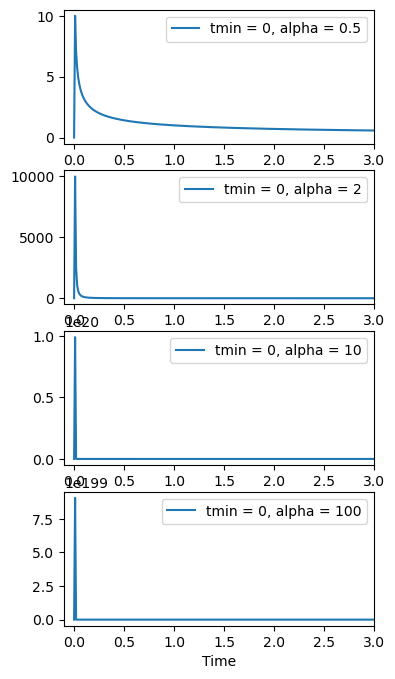

In [40]:
t = np.linspace(0, 10, 1000)
plt.figure(figsize=(4, 8))
plt.subplot(411)
dtd = ut_old.D_t_NS(t,C = 1, b = 0.5, tmin = 0, vmean = 180, Renc = 0.5,key_PDF = 'delta',cutoff=False)
plt.plot(t, dtd, label = "tmin = 0, alpha = 0.5")
plt.legend()
plt.xlim(-0.1,3)

plt.subplot(412)
dtd = ut_old.D_t_NS(t,C = 1, b = 2, tmin = 0, vmean = 180, Renc = 0.5,key_PDF = 'delta',cutoff=False)
plt.plot(t, dtd, label = "tmin = 0, alpha = 2")
plt.legend()
plt.xlim(-0.1,3)

plt.subplot(413)
dtd = ut_old.D_t_NS(t,C = 1, b = 10, tmin = 0, vmean = 180, Renc = 0.5,key_PDF = 'delta',cutoff=False)
plt.plot(t, dtd, label = "tmin = 0, alpha = 10")
plt.legend()
plt.xlim(-0.1,3)

plt.subplot(414)
dtd = ut_old.D_t_NS(t,C = 1, b = 100, tmin = 0, vmean = 180, Renc = 0.5,key_PDF = 'delta',cutoff=False)
plt.plot(t, dtd, label = "tmin = 0, alpha = 100")
plt.legend()
plt.xlim(-0.1,3)
plt.xlabel("Time")

In [63]:
# use nsbh parameter as borrowed from bns parameters 
rate_nsbh  = copy.deepcopy(rate)
mej_nsbh   = copy.deepcopy(mej)
alpha_nsbh = copy.deepcopy(alpha)
tdmin_nsbh = copy.deepcopy(tdmin)

outdat = {}
outdat['pop'] = {}
outdat['yield'] = {}
outdat['frac'] = {}

half_mej = 0.5 * mej 

Fe_H, r_Fe, rate_evolutions = ut_new.rproc_evolution_nsbh(
                                    rate,
                                    rate_nsbh,
                                    half_mej,
                                    half_mej,
                                    -alpha,
                                    -alpha_nsbh,
                                    tdmin,
                                    tdmin_nsbh,
                                    Xcoll,
                                    f_NSgal=0.5,nppdt=20,
                                    add_NSBH = True)

Rbns, Rnsbh, Rcoll, Xs, zs, ts = rate_evolutions

outdat['pop'][idx] = np.array([mej,rate,alpha,tdmin,mej_nsbh,rate_nsbh,alpha_nsbh,tdmin_nsbh,Xcoll])
outdat['yield'][idx] = {}
outdat['yield'][idx]['Fe_H'] = Fe_H
outdat['yield'][idx]['Eu_Fe'] = r_Fe
outdat['frac'][idx] = {}
outdat['frac'][idx]['Rbns'] = Rbns
outdat['frac'][idx]['Rnsbh'] = Rnsbh
outdat['frac'][idx]['Rcoll'] = Rcoll
outdat['frac'][idx]['Xs'] = Xs
outdat['frac'][idx]['z'] = zs
outdat['frac'][idx]['t'] = ts

Rcoll0 = Rcoll[-1]
mcoll = (mej*rate+mej_nsbh*rate_nsbh)/((1./Xcoll - 1.)*Rcoll0)
num = cumtrapz(mej*Rbns+mej_nsbh*Rnsbh,ts)
denom = cumtrapz(mcoll*Rcoll,ts)
Xts = 1./(1.+num/denom)

outdat['frac'][idx]['X'] = list(Xts)+[Xts[-1]]

outdat_mej_half = copy.deepcopy(outdat)

tmin ..:  0.4658872381543552 13.46698394706188 0.4658872381543552 13.46698394706188


/home/muhammed.saleem/projects/rprocess/bns-nsbh-rproc/explore/utils_nsbh.py:289: RuntimeWarning: The iteration is not making good progress, as measured by the 
  improvement from the last ten iterations.
  sol = fsolve(t_root,z_guess,args=tloc,xtol=1e-14)
/home/muhammed.saleem/projects/rprocess/bns-nsbh-rproc/explore/utils_nsbh.py:289: RuntimeWarning: xtol=0.000000 is too small, no further improvement in the approximate
  solution is possible.
  sol = fsolve(t_root,z_guess,args=tloc,xtol=1e-14)
/home/muhammed.saleem/projects/rprocess/bns-nsbh-rproc/explore/utils_nsbh.py:354: RuntimeWarning: invalid value encountered in divide
  result = C * heaviside(t-tmin,1.) / t**b
/home/muhammed.saleem/projects/rprocess/bns-nsbh-rproc/explore/utils_nsbh.py:362: RuntimeWarning: invalid value encountered in divide
  result = C * heaviside(t-tmin,1.) / t**b
/home/muhammed.saleem/projects/rprocess/bns-nsbh-rproc/explore/utils_nsbh.py:354: RuntimeWarning: invalid value encountered in power
  result = C